In [121]:
# =========================
# 1. IMPORT LIBRARIES
# =========================

# Data handling
import pandas as pd
import numpy as np
#
# ML preprocessing & evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model
import sklearn
from sklearn.ensemble import RandomForestClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.pipeline import Pipeline
# OR if you aren't using imbalanced-learn samplers (like SMOTE):
# from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

# Model saving
import joblib



In [122]:
# =========================
# 2. LOAD DATA
# =========================

df = pd.read_csv("healthcare_disease_prediction_dataset.csv")
print("First rows:")
print(df.head())

print("last rows:")
print(df.tail())

print("\nDataset Info:")
print(df.info())
print("summary information:")
print(df.describe())



First rows:
   Age  Gender  Alzheimer's Disease Blood Pressure Cholesterol Glucose  \
0   69    Male                    0           High        High    High   
1   32    Male                    0            Low        High  Normal   
2   89  Female                    0         Normal        High  Normal   
3   78    Male                    0           High        High    High   
4   38    Male                    0            Low      Normal  Normal   

  Smoking Alcohol Consumption Exercise        BMI Family History  \
0     Yes                  No       No  35.671099             No   
1     Yes                  No      Yes  38.554188            Yes   
2      No                  No      Yes  18.932964            Yes   
3      No                  No      Yes  21.806350            Yes   
4     Yes                 Yes      Yes  37.552683             No   

   Heart Disease  Diabetes  Stroke  Kidney Disease  Cancer  COPD  \
0              1         0       0               0       1     0  

In [123]:
# =========================
# 3. CLEAN COLUMN NAMES
# =========================

# Remove hidden spaces in column names
df.columns = df.columns.str.strip()



In [147]:
# =========================
# 4. CLEAN TARGET COLUMN
# =========================

# Normalize text (case + spaces)
df["Diabetes"] = (
    df["Diabetes"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["Diabetes"] = df["Diabetes"].astype(str).str.strip().str.lower()


In [125]:
# 5. Remove duplicates
df = df.drop_duplicates()

In [128]:
# 6. LABEL ENCODING
ln=LabelEncoder()
feature=[
    "Gender","Blood Pressure","Cholesterol","Glucose","Smoking","Alcohol Consumption","Exercise","Family History"

 ]
for col in feature:
     df[col]=ln.fit_transform(df[col])

y=ln.fit_transform(df["Diabetes"])


In [129]:
# =========================
# 7. CLEAN FEATURES
# =========================

feature_cols = [
     "Age","Gender","Alzheimer's Disease","Blood Pressure","Cholesterol","Glucose","Smoking","Alcohol Consumption","Exercise","BMI","Family History","Heart Disease","Stroke","Kidney Disease","Cancer","COPD","Liver Disease","Parkinson's Disease","Tuberculosis"
     ]

df = df.dropna(subset=["Diabetes"])

In [131]:
# =========================
# 8. SPLIT DATA
# =========================

X = df[feature_cols]  # Inputs (symptoms)
y = df["Diabetes"]   # Target (labels)


In [132]:
 # =========================
# 9. TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # keeps class balance
)

In [133]:
# =========================
# 10. SMOTE (BALANCING)
# =========================

smote = SMOTE(random_state=42, k_neighbors=2)

In [134]:
# =========================
# 11. SCALING
# =========================

scaler = StandardScaler()

In [137]:
# =========================
# 12. MODEL
# =========================

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

In [138]:
# =========================
# 13. PIPELINE
# =========================

pipeline = ImbPipeline(steps=[
    ("scaler", scaler),
    ("smote", smote),
    ("model", model)
])

In [139]:
# =========================
# 14. CROSS VALIDATION
# =========================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_weighted"
)

print("\nCV Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())


CV Scores: [0.73536021 0.73262032 0.72214927 0.72304179 0.70627208]
Mean CV F1: 0.7238887336329398


In [140]:
# =========================
# 15. TRAIN MODEL
# =========================

pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,2
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500


In [141]:
# =========================
# 16. PREDICTIONS
# =========================

y_pred = pipeline.predict(X_test)

In [142]:
# =========================
# 17. EVALUATION REPORT
# =========================

print("\nCLASSIFICATION REPORT:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))


CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.82      0.96      0.88       163
           1       0.30      0.08      0.13        37

    accuracy                           0.80       200
   macro avg       0.56      0.52      0.51       200
weighted avg       0.72      0.80      0.74       200



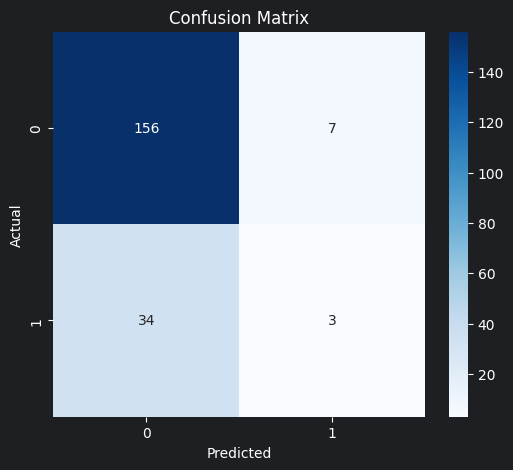

In [144]:
# =========================
# 18. CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

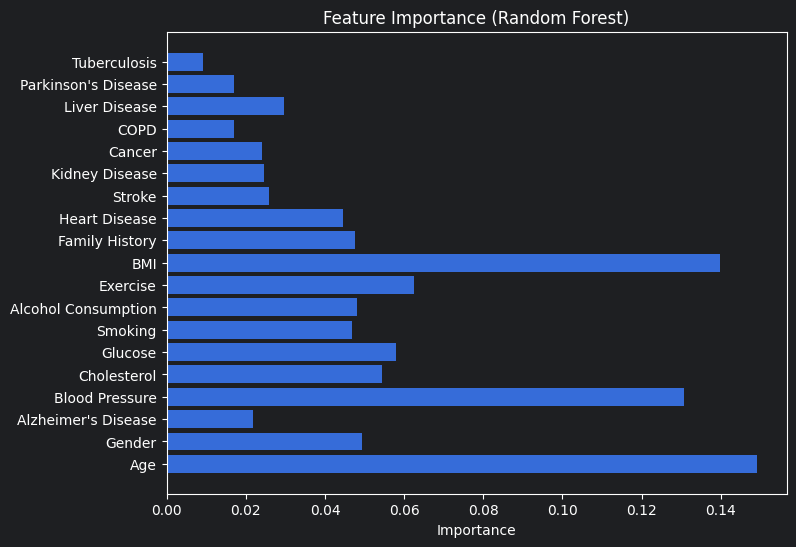

In [145]:
# =========================
# 19. FEATURE IMPORTANCE
# =========================

importances = pipeline.named_steps["model"].feature_importances_

plt.figure(figsize=(8, 6))
plt.barh(feature_cols, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [148]:
# =========================
# 20. SAVE MODEL
# =========================

model_info = {
    "model": model,
    "sklearn_version": sklearn.__version__
}

joblib.dump(model_info, "model_bundle.pkl")
joblib.dump(pipeline, "model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("\nModel saved successfully!")


Model saved successfully!
